<a href="https://colab.research.google.com/github/rodrigologin0-cpu/Rodrigo-de-Souza-Lima/blob/main/NARX_AG_Rondon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NARX POLINOMIAL + OTIMIZAÇÃO AUTOMÁTICA DO ALGORITMO GENÉTICO
#
# Camada externa:
#   - escolhe hiperparâmetros do AG
#
# Camada interna:
#   - AG escolhe:
#       * atrasos de Y
#       * atrasos das entradas U
#       * grau do polinômio
#       * subconjunto de termos
#
# Foco:
#   - menor erro
#   - menor complexidade
#   - implementação em PLC
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import time

from google.colab import files
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================================
# 1. UPLOAD DO ARQUIVO
# ============================================================

print("Faça upload do arquivo Excel (.xlsx)")
uploaded = files.upload()

arquivo = list(uploaded.keys())[0]
df = pd.read_excel(arquivo).dropna().reset_index(drop=True)

print("\nColunas disponíveis:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

Faça upload do arquivo Excel (.xlsx)


Saving Temperatura.xlsx to Temperatura.xlsx

Colunas disponíveis:
0: TEMP
1: VAZÃO
2: POTÊNCIA
3: VALVULA
4: TEMP_1
5: TEMP_2


In [3]:
# ============================================================
# 2. CONFIGURAÇÕES DO PROBLEMA NARX
# ============================================================

col_y = input("\nDigite o nome da variável objetivo Y: ")

n_inputs = int(input("Quantas entradas exógenas deseja usar? "))

cols_u = []
for i in range(n_inputs):
    col = input(f"Digite o nome da entrada U{i+1}: ")
    cols_u.append(col)

horizonte = int(input("Horizonte de previsão em passos. Exemplo: 1, 30, 120: "))

max_lag_y = int(input("Máximo de atrasos da saída Y. Exemplo: 5: "))
max_lag_u = int(input("Máximo de atrasos das entradas U. Exemplo: 5: "))

graus_possiveis = input("Graus polinomiais possíveis. Exemplo: 1,2: ")
graus_possiveis = [int(g.strip()) for g in graus_possiveis.split(",")]

usar_amostra = input("Usar apenas parte dos dados para acelerar? (s/n): ").lower() == "s"

if usar_amostra:
    n_amostras = int(input("Número de amostras. Exemplo: 30000: "))
    df = df.iloc[:n_amostras].copy()

criterio = input("Critério principal: mae ou rmse? ").lower()
if criterio not in ["mae", "rmse"]:
    criterio = "rmse"



Digite o nome da variável objetivo Y: TEMP
Quantas entradas exógenas deseja usar? 5
Digite o nome da entrada U1: VAZÃO
Digite o nome da entrada U2: POTÊNCIA
Digite o nome da entrada U3: VALVULA
Digite o nome da entrada U4: TEMP_1
Digite o nome da entrada U5: TEMP_2
Horizonte de previsão em passos. Exemplo: 1, 30, 120: 120
Máximo de atrasos da saída Y. Exemplo: 5: 5
Máximo de atrasos das entradas U. Exemplo: 5: 5
Graus polinomiais possíveis. Exemplo: 1,2: 1,2
Usar apenas parte dos dados para acelerar? (s/n): n
Critério principal: mae ou rmse? mae


In [8]:
# ============================================================
# 3. ESPAÇO DE BUSCA DOS HIPERPARÂMETROS DO AG
# ============================================================

print("\nAgora configure as opções para otimizar o Algoritmo Genético.")

pop_size_options = input("Opções de população. Exemplo: 20,30,40: ")
pop_size_options = [int(x.strip()) for x in pop_size_options.split(",")]

generations_options = input("Opções de gerações. Exemplo: 20,40,60: ")
generations_options = [int(x.strip()) for x in generations_options.split(",")]

mutation_options = input("Opções de taxa de mutação. Exemplo: 0.02,0.05,0.10: ")
mutation_options = [float(x.strip()) for x in mutation_options.split(",")]

max_terms_options = input("Opções de máximo de termos. Exemplo: 5,10,15: ")
max_terms_options = [int(x.strip()) for x in max_terms_options.split(",")]

n_trials = int(input("Quantas combinações aleatórias testar? Exemplo: 10: "))
n_repeats = int(input("Quantas repetições por combinação? Exemplo: 3: "))

# Penalizações do modelo
lambda_terms = float(input("Penalização por termo no modelo. Exemplo: 0.002: "))
lambda_degree = float(input("Penalização por grau polinomial. Exemplo: 0.01: "))
lambda_lags = float(input("Penalização por atraso. Exemplo: 0.001: "))

# Penalização externa
lambda_tempo = float(input("Penalização por tempo de execução. Exemplo: 0.0001: "))


Agora configure as opções para otimizar o Algoritmo Genético.
Opções de população. Exemplo: 20,30,40: 20,30
Opções de gerações. Exemplo: 20,40,60: 20,40
Opções de taxa de mutação. Exemplo: 0.02,0.05,0.10: 0.02,0.05,0.10
Opções de máximo de termos. Exemplo: 5,10,15: 5,10,15
Quantas combinações aleatórias testar? Exemplo: 10: 5
Quantas repetições por combinação? Exemplo: 3: 3
Penalização por termo no modelo. Exemplo: 0.002: 0.002
Penalização por grau polinomial. Exemplo: 0.01: 0.01
Penalização por atraso. Exemplo: 0.001: 0.001
Penalização por tempo de execução. Exemplo: 0.0001: 0.0001


In [9]:
# ============================================================
# 4. FUNÇÕES DE CONSTRUÇÃO DO MODELO NARX
# ============================================================

def criar_base_narx(df, col_y, cols_u, n_lags_y, n_lags_u, horizonte):
    data = pd.DataFrame(index=df.index)

    # Saída atual
    data[f"{col_y}_t"] = df[col_y]

    # Atrasos da saída
    for lag in range(1, n_lags_y + 1):
        data[f"{col_y}_t-{lag}"] = df[col_y].shift(lag)

    # Entradas atuais e atrasadas
    for col in cols_u:
        data[f"{col}_t"] = df[col]

        for lag in range(1, n_lags_u + 1):
            data[f"{col}_t-{lag}"] = df[col].shift(lag)

    # Alvo futuro corretamente alinhado
    data[f"{col_y}_real_t+{horizonte}"] = df[col_y].shift(-horizonte)

    data = data.dropna().reset_index(drop=True)

    X_base = data.drop(columns=[f"{col_y}_real_t+{horizonte}"])
    y_target = data[f"{col_y}_real_t+{horizonte}"].values

    return X_base, y_target


def preparar_matriz(df, col_y, cols_u, n_lags_y, n_lags_u, grau, horizonte):
    X_base, y_target = criar_base_narx(
        df, col_y, cols_u, n_lags_y, n_lags_u, horizonte
    )

    train_size = int(len(X_base) * 0.8)

    X_train_base = X_base.iloc[:train_size]
    X_test_base  = X_base.iloc[train_size:]

    y_train = y_target[:train_size]
    y_test  = y_target[train_size:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_base)
    X_test_scaled  = scaler.transform(X_test_base)

    poly = PolynomialFeatures(
        degree=grau,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly  = poly.transform(X_test_scaled)

    feature_names = poly.get_feature_names_out(X_base.columns)

    return {
        "X_train_poly": X_train_poly,
        "X_test_poly": X_test_poly,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": feature_names,
        "scaler": scaler,
        "poly": poly,
        "X_base_cols": X_base.columns
    }


def avaliar_modelo(X_train, X_test, y_train, y_test):
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)

    return {
        "modelo": modelo,
        "y_pred_train": y_pred_train,
        "y_pred_test": y_pred_test,
        "mae_train": mean_absolute_error(y_train, y_pred_train),
        "rmse_train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "r2_train": r2_score(y_train, y_pred_train),
        "mae_test": mean_absolute_error(y_test, y_pred_test),
        "rmse_test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
        "r2_test": r2_score(y_test, y_pred_test)
    }

# Cache global para acelerar
cache_matrizes = {}

def get_matriz(n_lags_y, n_lags_u, grau):
    key = (n_lags_y, n_lags_u, grau)

    if key not in cache_matrizes:
        cache_matrizes[key] = preparar_matriz(
            df, col_y, cols_u, n_lags_y, n_lags_u, grau, horizonte
        )

    return cache_matrizes[key]


In [10]:
# ============================================================
# 5. ALGORITMO GENÉTICO INTERNO
# ============================================================

def rodar_ag_interno(
    pop_size,
    n_generations,
    mutation_rate,
    max_terms_allowed,
    seed=None
):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    def criar_individuo():
        lags_y = random.randint(1, max_lag_y)
        lags_u = random.randint(1, max_lag_u)
        grau = random.choice(graus_possiveis)

        matriz = get_matriz(lags_y, lags_u, grau)
        n_features = matriz["X_train_poly"].shape[1]

        n_terms = random.randint(1, min(max_terms_allowed, n_features))

        mask = np.zeros(n_features, dtype=bool)
        idx = random.sample(range(n_features), n_terms)
        mask[idx] = True

        return {
            "lags_y": lags_y,
            "lags_u": lags_u,
            "grau": grau,
            "mask": mask
        }

    def ajustar_mask(ind):
        matriz = get_matriz(ind["lags_y"], ind["lags_u"], ind["grau"])
        n_features = matriz["X_train_poly"].shape[1]

        mask = ind["mask"]

        if len(mask) != n_features:
            nova_mask = np.zeros(n_features, dtype=bool)
            n_copy = min(len(mask), n_features)
            nova_mask[:n_copy] = mask[:n_copy]
            mask = nova_mask

        if np.sum(mask) == 0:
            mask[random.randint(0, n_features - 1)] = True

        while np.sum(mask) > max_terms_allowed:
            idx_true = np.where(mask)[0]
            mask[random.choice(idx_true)] = False

        ind["mask"] = mask
        return ind

    def fitness(ind):
        ind = ajustar_mask(ind)

        matriz = get_matriz(ind["lags_y"], ind["lags_u"], ind["grau"])

        mask = ind["mask"]
        n_terms = int(np.sum(mask))

        X_train = matriz["X_train_poly"][:, mask]
        X_test  = matriz["X_test_poly"][:, mask]

        y_train = matriz["y_train"]
        y_test  = matriz["y_test"]

        try:
            r = avaliar_modelo(X_train, X_test, y_train, y_test)

            erro_base = r["mae_test"] if criterio == "mae" else r["rmse_test"]

            score = (
                erro_base
                * (1 + lambda_terms * n_terms)
                * (1 + lambda_degree * (ind["grau"] - 1))
                * (1 + lambda_lags * (ind["lags_y"] + ind["lags_u"]))
            )

            return score, r

        except Exception:
            return 1e12, None

    def crossover(p1, p2):
        child = {}

        child["lags_y"] = random.choice([p1["lags_y"], p2["lags_y"]])
        child["lags_u"] = random.choice([p1["lags_u"], p2["lags_u"]])
        child["grau"] = random.choice([p1["grau"], p2["grau"]])

        matriz = get_matriz(child["lags_y"], child["lags_u"], child["grau"])
        n_features = matriz["X_train_poly"].shape[1]

        m1 = ajustar_mask(p1.copy())["mask"]
        m2 = ajustar_mask(p2.copy())["mask"]

        mask1 = np.zeros(n_features, dtype=bool)
        mask2 = np.zeros(n_features, dtype=bool)

        n1 = min(len(m1), n_features)
        n2 = min(len(m2), n_features)

        mask1[:n1] = m1[:n1]
        mask2[:n2] = m2[:n2]

        child_mask = np.zeros(n_features, dtype=bool)

        for i in range(n_features):
            child_mask[i] = random.choice([mask1[i], mask2[i]])

        child["mask"] = child_mask
        child = ajustar_mask(child)

        return child

    def mutate(ind):
        ind = ind.copy()

        if random.random() < mutation_rate:
            ind["lags_y"] = random.randint(1, max_lag_y)

        if random.random() < mutation_rate:
            ind["lags_u"] = random.randint(1, max_lag_u)

        if random.random() < mutation_rate:
            ind["grau"] = random.choice(graus_possiveis)

        ind = ajustar_mask(ind)

        mask = ind["mask"].copy()

        for i in range(len(mask)):
            if random.random() < mutation_rate:
                mask[i] = not mask[i]

        ind["mask"] = mask
        ind = ajustar_mask(ind)

        return ind

    population = [criar_individuo() for _ in range(pop_size)]

    best_ind = None
    best_score = 1e12
    best_result = None
    history = []

    for gen in range(n_generations):
        scored = []

        for ind in population:
            score, result = fitness(ind)
            scored.append((score, ind, result))

        scored.sort(key=lambda x: x[0])

        if scored[0][0] < best_score:
            best_score = scored[0][0]
            best_ind = scored[0][1].copy()
            best_result = scored[0][2]

        history.append(best_score)

        elite_count = max(2, pop_size // 5)
        new_population = [scored[i][1].copy() for i in range(elite_count)]

        while len(new_population) < pop_size:
            p1 = random.choice(scored[:max(2, pop_size//2)])[1]
            p2 = random.choice(scored[:max(2, pop_size//2)])[1]

            child = crossover(p1, p2)
            child = mutate(child)

            new_population.append(child)

        population = new_population

    best_ind = ajustar_mask(best_ind)

    matriz_best = get_matriz(
        best_ind["lags_y"],
        best_ind["lags_u"],
        best_ind["grau"]
    )

    mask_best = best_ind["mask"]
    selected_features = matriz_best["feature_names"][mask_best]

    return {
        "best_score": best_score,
        "best_ind": best_ind,
        "best_result": best_result,
        "history": history,
        "selected_features": selected_features,
        "matriz_best": matriz_best
    }


In [11]:
# ============================================================
# 6. OTIMIZAÇÃO EXTERNA DOS HIPERPARÂMETROS DO AG
# ============================================================

espaco_parametros = []

for _ in range(n_trials):
    cfg = {
        "pop_size": random.choice(pop_size_options),
        "n_generations": random.choice(generations_options),
        "mutation_rate": random.choice(mutation_options),
        "max_terms_allowed": random.choice(max_terms_options)
    }

    if cfg not in espaco_parametros:
        espaco_parametros.append(cfg)

resultados_externos = []

melhor_global = None
melhor_score_externo = 1e12

print("\n============================================================")
print("INICIANDO OTIMIZAÇÃO DOS HIPERPARÂMETROS DO AG")
print("============================================================")

for i, cfg in enumerate(espaco_parametros):

    print(f"\nConfiguração {i+1}/{len(espaco_parametros)}")
    print(cfg)

    scores = []
    maes = []
    rmses = []
    r2s = []
    n_termos_list = []
    tempos = []
    execucoes = []

    for rep in range(n_repeats):
        t0 = time.time()

        saida = rodar_ag_interno(
            pop_size=cfg["pop_size"],
            n_generations=cfg["n_generations"],
            mutation_rate=cfg["mutation_rate"],
            max_terms_allowed=cfg["max_terms_allowed"],
            seed=1000 + rep
        )

        tempo_exec = time.time() - t0

        ind = saida["best_ind"]
        res = saida["best_result"]

        n_termos = int(np.sum(ind["mask"]))

        erro_base = res["mae_test"] if criterio == "mae" else res["rmse_test"]

        score_externo = (
            erro_base
            * (1 + lambda_terms * n_termos)
            * (1 + lambda_degree * (ind["grau"] - 1))
            * (1 + lambda_lags * (ind["lags_y"] + ind["lags_u"]))
            * (1 + lambda_tempo * tempo_exec)
        )

        scores.append(score_externo)
        maes.append(res["mae_test"])
        rmses.append(res["rmse_test"])
        r2s.append(res["r2_test"])
        n_termos_list.append(n_termos)
        tempos.append(tempo_exec)
        execucoes.append(saida)

        print(
            f"  Rep {rep+1}/{n_repeats} | "
            f"Score={score_externo:.5f} | "
            f"MAE={res['mae_test']:.5f} | "
            f"RMSE={res['rmse_test']:.5f} | "
            f"Termos={n_termos} | "
            f"LagsY={ind['lags_y']} | "
            f"LagsU={ind['lags_u']} | "
            f"Grau={ind['grau']} | "
            f"Tempo={tempo_exec:.2f}s"
        )

    score_medio = np.mean(scores)

    linha = {
        "pop_size": cfg["pop_size"],
        "n_generations": cfg["n_generations"],
        "mutation_rate": cfg["mutation_rate"],
        "max_terms_allowed": cfg["max_terms_allowed"],
        "score_medio": score_medio,
        "score_std": np.std(scores),
        "mae_medio": np.mean(maes),
        "rmse_medio": np.mean(rmses),
        "r2_medio": np.mean(r2s),
        "n_termos_medio": np.mean(n_termos_list),
        "tempo_medio_s": np.mean(tempos)
    }

    resultados_externos.append(linha)

    melhor_rep_idx = int(np.argmin(scores))

    if score_medio < melhor_score_externo:
        melhor_score_externo = score_medio
        melhor_global = {
            "cfg": cfg,
            "resultado": execucoes[melhor_rep_idx],
            "score_medio": score_medio,
            "linha": linha
        }



INICIANDO OTIMIZAÇÃO DOS HIPERPARÂMETROS DO AG

Configuração 1/5
{'pop_size': 20, 'n_generations': 20, 'mutation_rate': 0.05, 'max_terms_allowed': 15}
  Rep 1/3 | Score=6.72353 | MAE=6.56922 | RMSE=8.39585 | Termos=7 | LagsY=5 | LagsU=3 | Grau=1 | Tempo=13.47s
  Rep 2/3 | Score=6.67426 | MAE=6.43405 | RMSE=8.15175 | Termos=11 | LagsY=3 | LagsU=1 | Grau=2 | Tempo=9.50s
  Rep 3/3 | Score=6.74800 | MAE=6.62842 | RMSE=8.48247 | Termos=6 | LagsY=4 | LagsU=1 | Grau=1 | Tempo=9.64s

Configuração 2/5
{'pop_size': 20, 'n_generations': 40, 'mutation_rate': 0.02, 'max_terms_allowed': 5}
  Rep 1/3 | Score=6.74211 | MAE=6.62296 | RMSE=8.47613 | Termos=5 | LagsY=5 | LagsU=2 | Grau=1 | Tempo=9.06s
  Rep 2/3 | Score=6.74311 | MAE=6.61737 | RMSE=8.46978 | Termos=5 | LagsY=4 | LagsU=4 | Grau=1 | Tempo=9.05s
  Rep 3/3 | Score=6.79644 | MAE=6.69753 | RMSE=8.57143 | Termos=4 | LagsY=5 | LagsU=1 | Grau=1 | Tempo=7.10s

Configuração 3/5
{'pop_size': 30, 'n_generations': 20, 'mutation_rate': 0.1, 'max_terms_

In [12]:
# ============================================================
# 7. RESULTADOS FINAIS
# ============================================================

df_resultados = pd.DataFrame(resultados_externos)
df_resultados = df_resultados.sort_values("score_medio").reset_index(drop=True)

print("\n============================================================")
print("RESULTADO DA OTIMIZAÇÃO EXTERNA")
print("============================================================")
display(df_resultados)

print("\nMelhor configuração de hiperparâmetros do AG:")
print(melhor_global["cfg"])

saida_final = melhor_global["resultado"]
ind_final = saida_final["best_ind"]
res_final = saida_final["best_result"]
matriz_final = saida_final["matriz_best"]
features_final = saida_final["selected_features"]

print("\nMelhor modelo NARX encontrado:")
print(f"Horizonte: {horizonte}")
print(f"Lags Y: {ind_final['lags_y']}")
print(f"Lags U: {ind_final['lags_u']}")
print(f"Grau polinomial: {ind_final['grau']}")
print(f"Nº termos selecionados: {np.sum(ind_final['mask'])}")
print(f"MAE teste: {res_final['mae_test']:.5f}")
print(f"RMSE teste: {res_final['rmse_test']:.5f}")
print(f"R² teste: {res_final['r2_test']:.5f}")

print("\nTermos selecionados:")
for termo in features_final:
    print("-", termo)



RESULTADO DA OTIMIZAÇÃO EXTERNA


,pop_size,n_generations,mutation_rate,max_terms_allowed,score_medio,score_std,mae_medio,rmse_medio,r2_medio,n_termos_medio,tempo_medio_s
0,20,20,0.05,15,6.715263,0.030665,6.543899,8.343355,0.959764,8.000000,10.871446
1,20,40,0.10,15,6.738741,0.018225,6.615077,8.443893,0.958800,6.000000,16.127709
2,20,20,0.05,5,6.750424,0.014759,6.641049,8.494153,0.958309,5.000000,4.031583
3,20,40,0.02,5,6.760554,0.025377,6.645954,8.505782,0.958193,4.666667,8.400831
4,30,20,0.10,5,6.769932,0.023071,6.651961,8.508597,0.958166,5.000000,6.526427



Melhor configuração de hiperparâmetros do AG:
{'pop_size': 20, 'n_generations': 20, 'mutation_rate': 0.05, 'max_terms_allowed': 15}

Melhor modelo NARX encontrado:
Horizonte: 120
Lags Y: 3
Lags U: 1
Grau polinomial: 2
Nº termos selecionados: 11
MAE teste: 6.43405
RMSE teste: 8.15175
R² teste: 0.96160

Termos selecionados:
- TEMP_t
- TEMP_t-1
- TEMP_t-3
- VAZÃO_t
- VAZÃO_t-1
- VALVULA_t
- TEMP_2_t-1
- TEMP_t-1 VAZÃO_t
- TEMP_t-1 TEMP_1_t-1
- TEMP_1_t TEMP_2_t-1
- TEMP_1_t-1 TEMP_2_t



Quantas amostras deseja mostrar no gráfico? Exemplo: 1000: 1500


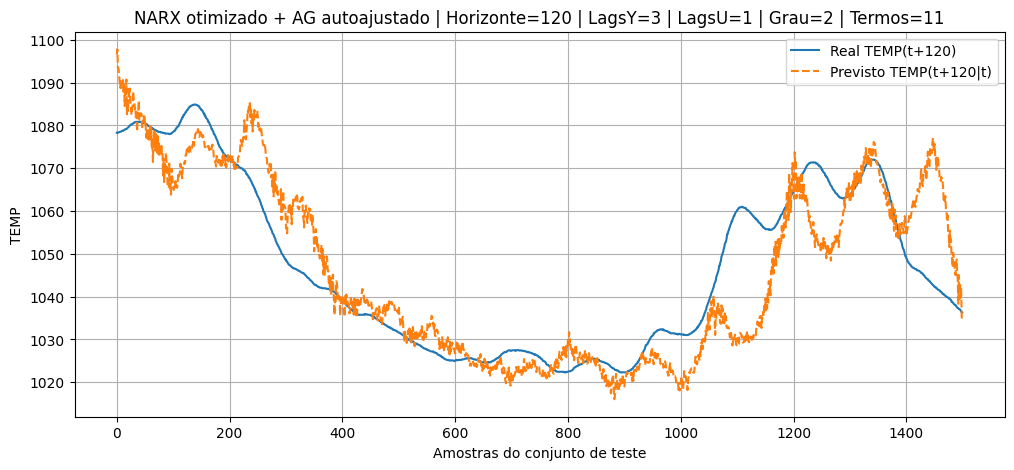

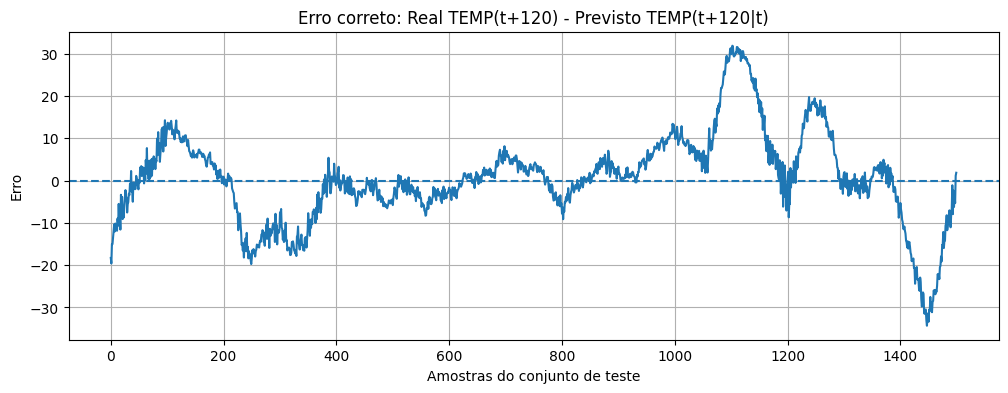

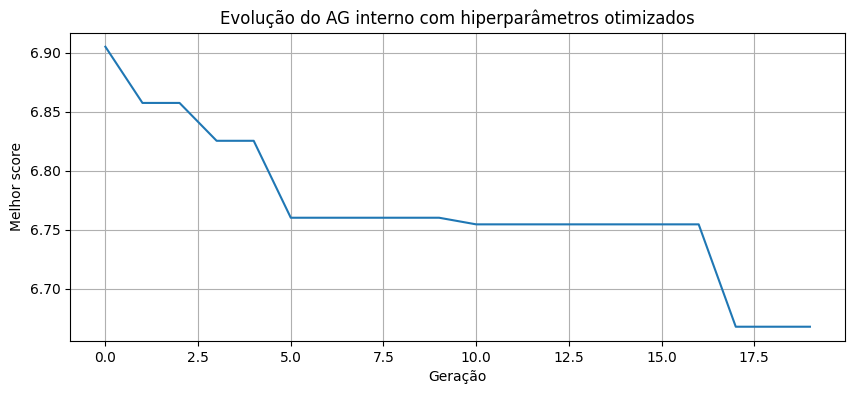

In [13]:
# ============================================================
# 8. GRÁFICOS
# ============================================================

n_plot = int(input("\nQuantas amostras deseja mostrar no gráfico? Exemplo: 1000: "))

y_test = matriz_final["y_test"]
y_pred = res_final["y_pred_test"]
erro = y_test - y_pred

plt.figure(figsize=(12,5))
plt.plot(y_test[:n_plot], label=f"Real {col_y}(t+{horizonte})")
plt.plot(y_pred[:n_plot], linestyle="--", label=f"Previsto {col_y}(t+{horizonte}|t)")
plt.title(
    f"NARX otimizado + AG autoajustado | Horizonte={horizonte} | "
    f"LagsY={ind_final['lags_y']} | LagsU={ind_final['lags_u']} | "
    f"Grau={ind_final['grau']} | Termos={np.sum(ind_final['mask'])}"
)
plt.xlabel("Amostras do conjunto de teste")
plt.ylabel(col_y)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.plot(erro[:n_plot])
plt.axhline(0, linestyle="--")
plt.title(
    f"Erro correto: Real {col_y}(t+{horizonte}) - Previsto {col_y}(t+{horizonte}|t)"
)
plt.xlabel("Amostras do conjunto de teste")
plt.ylabel("Erro")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(saida_final["history"])
plt.title("Evolução do AG interno com hiperparâmetros otimizados")
plt.xlabel("Geração")
plt.ylabel("Melhor score")
plt.grid(True)
plt.show()


In [14]:
# ============================================================
# 9. EXPORTAÇÃO
# ============================================================

coef = res_final["modelo"].coef_
bias = res_final["modelo"].intercept_

df_coef = pd.DataFrame({
    "Termo": features_final,
    "Coeficiente": coef
})

df_coef.loc[len(df_coef)] = ["Bias", bias]

df_info_modelo = pd.DataFrame([{
    "Horizonte": horizonte,
    "Lags_Y": ind_final["lags_y"],
    "Lags_U": ind_final["lags_u"],
    "Grau": ind_final["grau"],
    "N_Termos": int(np.sum(ind_final["mask"])),
    "MAE_Teste": res_final["mae_test"],
    "RMSE_Teste": res_final["rmse_test"],
    "R2_Teste": res_final["r2_test"],
    "Score_Medio_Externo": melhor_global["score_medio"],
    "pop_size": melhor_global["cfg"]["pop_size"],
    "n_generations": melhor_global["cfg"]["n_generations"],
    "mutation_rate": melhor_global["cfg"]["mutation_rate"],
    "max_terms_allowed": melhor_global["cfg"]["max_terms_allowed"]
}])

df_resultados.to_excel("resultado_otimizacao_hiperparametros_AG.xlsx", index=False)
df_coef.to_excel("coeficientes_melhor_narx_ag_autoajustado.xlsx", index=False)
df_info_modelo.to_excel("resumo_melhor_narx_ag_autoajustado.xlsx", index=False)

files.download("resultado_otimizacao_hiperparametros_AG.xlsx")
files.download("coeficientes_melhor_narx_ag_autoajustado.xlsx")
files.download("resumo_melhor_narx_ag_autoajustado.xlsx")

print("\nArquivos gerados:")
print("- resultado_otimizacao_hiperparametros_AG.xlsx")
print("- coeficientes_melhor_narx_ag_autoajustado.xlsx")
print("- resumo_melhor_narx_ag_autoajustado.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Arquivos gerados:
- resultado_otimizacao_hiperparametros_AG.xlsx
- coeficientes_melhor_narx_ag_autoajustado.xlsx
- resumo_melhor_narx_ag_autoajustado.xlsx
